# Seminar 2: Experimnnts

Author: Tung Nguyen

GitHub: https://github.com/tungedng2710

## 1. Monte Carlo Approximation for Pi estimation

In [1]:
# Set the number of samples
N <- 100000

# Generate N random points in the unit square
x <- runif(N)
y <- runif(N)

# Count how many points fall inside the unit circle
inside_circle <- sum(x^2 + y^2 <= 1)

# Estimate Pi using the ratio of points inside the circle
pi_estimate <- 4 * inside_circle / N

# Print the result
print(paste("Estimated value of pi:", pi_estimate))

[1] "Estimated value of pi: 3.14012"


## 2. Bayesian Inference for Poisson model



Observations are independent and identically distributed:
$$
    Y_i \mid \theta \sim \text{Poisson}(\theta), \quad i = 1, \dots, n
$$
Prior distribution for the Poisson rate parameter:
$$
    \theta \sim \text{Gamma}(a, b)
$$
Posterior distribution derived via Bayes' theorem:
$$
    \theta \mid y_1, \dots, y_n \sim \text{Gamma}\left(a + \sum_{i=1}^n y_i,\; b + n\right)
$$
Posterior predictive distribution for a new observation $\tilde{Y}$:
$$
    \tilde{Y} \mid y_1, \dots, y_n \sim \text{Negative Binomial}\left(a + \sum_{i=1}^n y_i,\; \frac{b + n}{b + n + 1}\right)
$$

Posterior mean: 3.545455 
Posterior mode: 3.454545 
95% CI: 2.521165 4.741634 


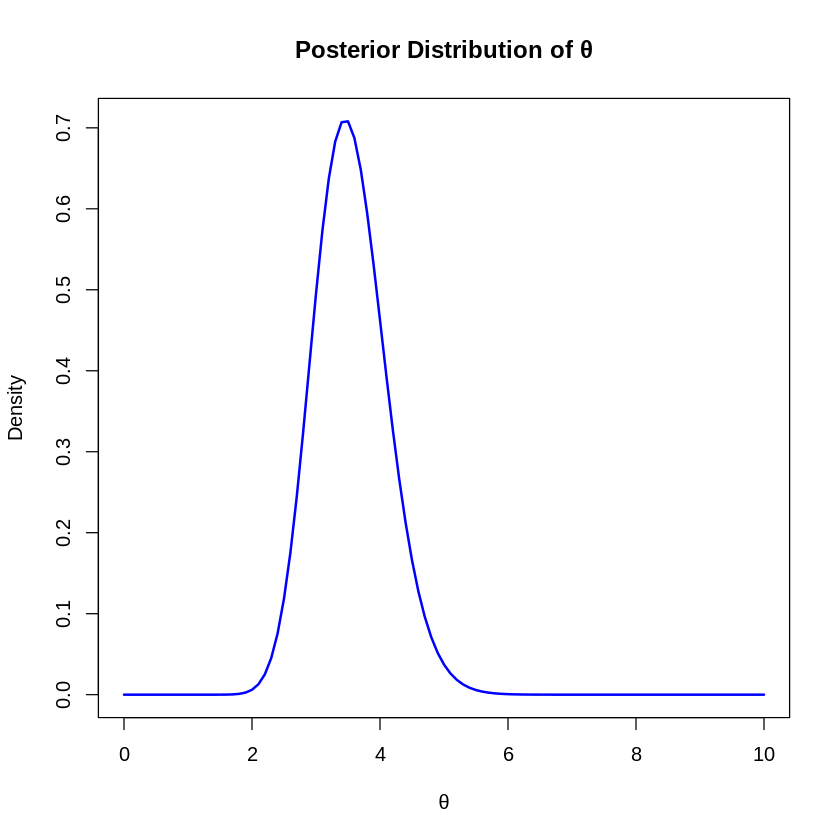

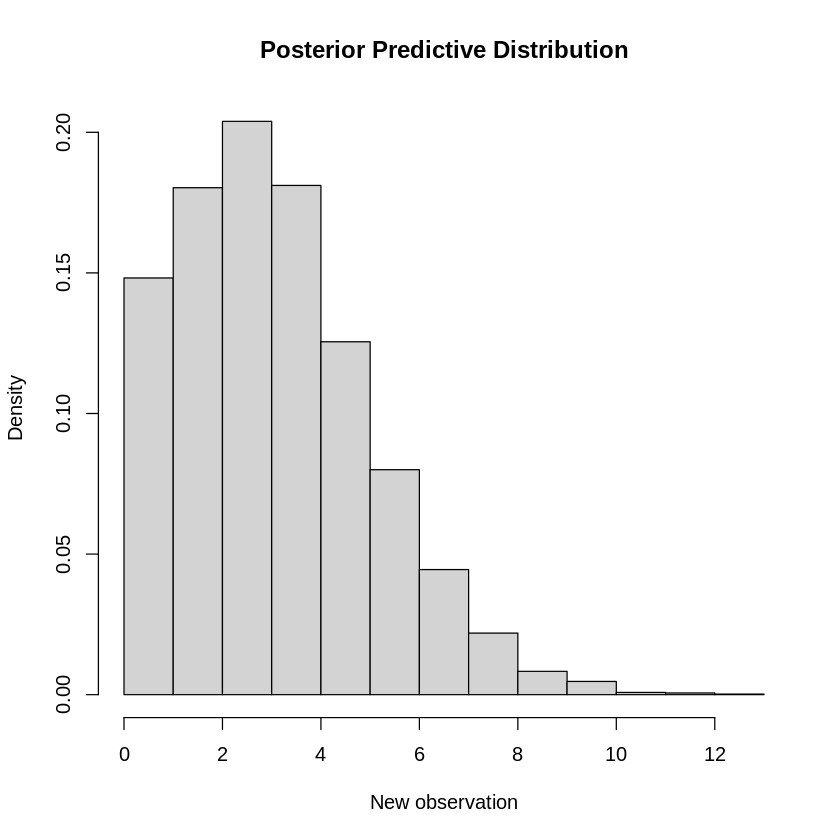

In [7]:
# Set prior parameters
a <- 2     # shape
b <- 1     # rate

# Simulated observed data (10 Poisson observations with mean ~3)
set.seed(42)
y <- rpois(10, lambda = 3)
n <- length(y)
sy <- sum(y)

# Posterior parameters
post_a <- a + sy
post_b <- b + n

# Posterior distribution is Gamma(post_a, post_b)
# Plot posterior
curve(dgamma(x, post_a, post_b),
      from = 0, to = 10,
      col = "blue", lwd = 2,
      ylab = "Density", xlab = expression(theta),
      main = "Posterior Distribution of θ")

# Posterior summary
posterior_mean <- post_a / post_b
posterior_mode <- if (post_a > 1) (post_a - 1) / post_b else 0
posterior_ci <- qgamma(c(0.025, 0.975), post_a, post_b)

cat("Posterior mean:", posterior_mean, "\n")
cat("Posterior mode:", posterior_mode, "\n")
cat("95% CI:", posterior_ci, "\n")

# Posterior predictive (new Poisson variable)
theta_sample <- rgamma(10000, post_a, post_b)
y_pred <- rpois(10000, lambda = theta_sample)

# Predictive plot
hist(y_pred, probability = TRUE, breaks = 15,
     main = "Posterior Predictive Distribution",
     xlab = "New observation", col = "lightgray")